# Monte Carlo sampling for asymmetric errors

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

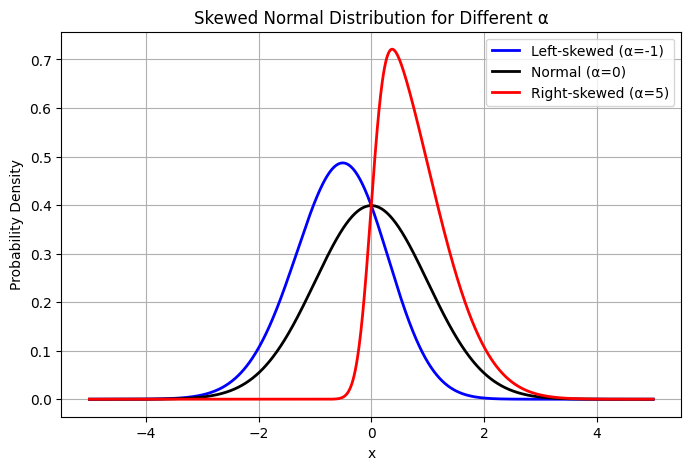

In [5]:
#Example for skewed normal distribution
x = np.linspace(-5, 5, 1000)

#Skewness parameters
alpha_values = [-1, 0, 5]  # Left-skewed, symmetric, right-skewed
colors = ['blue', 'black', 'red']
labels = ['Left-skewed (α=-1)', 'Normal (α=0)', 'Right-skewed (α=5)']

plt.figure(figsize=(8, 5))

for alpha, color, label in zip(alpha_values, colors, labels):
    pdf = skewnorm.pdf(x, alpha, loc=0, scale=1)  # Standard skew-normal
    plt.plot(x, pdf, color=color, label=label, linewidth=2)

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Skewed Normal Distribution for Different α')
plt.legend()
plt.grid()
plt.show()

In [6]:
# Planck TT data
data_Planck = np.loadtxt('./simulated_maps/experimental_data/COM_PowerSpect_CMB-TT-full_R3.01.txt')
ls_Planck_TT = data_Planck[:, 0]
dl_Planck_TT = data_Planck[:, 1]
sdl_Planck_TT_neg = data_Planck[:, 2]
sdl_Planck_TT_pos = data_Planck[:, 3]
round_ls_Pl_TT = np.round(ls_Planck_TT)

# Planck TE data
data_Planck = np.loadtxt('./simulated_maps/experimental_data/COM_PowerSpect_CMB-TE-full_R3.01.txt')
ls_Planck_TE = data_Planck[:, 0]
dl_Planck_TE = data_Planck[:, 1]
sdl_Planck_TE_neg = data_Planck[:, 2]
sdl_Planck_TE_pos = data_Planck[:, 3]
round_ls_Pl_TE = np.round(ls_Planck_TE)

# Planck EE data
data_Planck = np.loadtxt('./simulated_maps/experimental_data/COM_PowerSpect_CMB-EE-full_R3.01.txt')
ls_Planck_EE = data_Planck[:, 0]
dl_Planck_EE = data_Planck[:, 1]
sdl_Planck_EE_neg = data_Planck[:, 2]
sdl_Planck_EE_pos = data_Planck[:, 3]
round_ls_Pl_EE = np.round(ls_Planck_EE)

In [7]:
#Monte Carlo realizations
num_samples = 10000

#Function: generate asymmetric samples using a skewed normal distribution
def sample_asymmetric_distribution(Dl, err_neg, err_pos, num_samples):
    mean = Dl
    std_dev = (err_pos + err_neg) / 2  # Approximate std deviation
    skew_param = (err_pos - err_neg) / (err_pos + err_neg) * 10  #Skewness factor

    samples = skewnorm.rvs(a=skew_param, loc=mean, scale=std_dev, size=num_samples)
    return samples

## $\sigma_{\mathcal{C}_{\ell}^{TT}}$ sampling

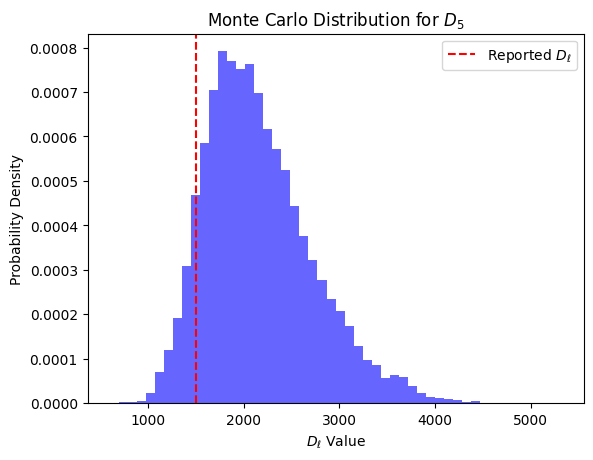

In [8]:
#Generate Monte Carlo samples for each l
samples_dict = {}
for i, l in enumerate(ls_Planck_TT):
    samples_dict[l] = sample_asymmetric_distribution(dl_Planck_TT[i], sdl_Planck_TT_neg[i], sdl_Planck_TT_pos[i], num_samples)

#Example: Plot histogram for one multipole (e.g., l=5)
l_example = 5
plt.hist(samples_dict[l_example], bins=50, density=True, alpha=0.6, color='b')
plt.axvline(dl_Planck_TT[ls_Planck_TT == l_example], color='r', linestyle='dashed', label="Reported $D_\ell$")
plt.xlabel("$D_\ell$ Value")
plt.ylabel("Probability Density")
plt.title(f"Monte Carlo Distribution for $D_{l_example}$")
plt.legend()
plt.show()

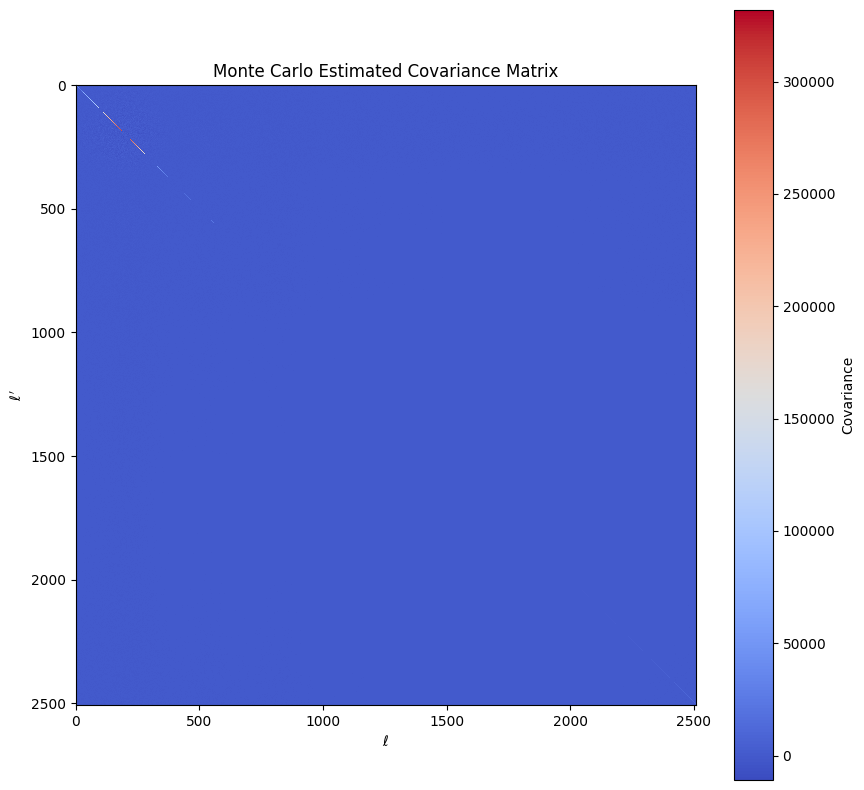

In [19]:
import csv
#Generate Monte Carlo samples for each l
samples_matrix = np.zeros((num_samples, len(ls_Planck_TT)))  # Shape (num_samples, num_ls_Planck_TT)

for i, l in enumerate(ls_Planck_TT):
    samples_matrix[:, i] = sample_asymmetric_distribution(dl_Planck_TT[i], sdl_Planck_TT_neg[i], sdl_Planck_TT_neg[i], num_samples)

#Compute the covariance matrix
cov_matrix = np.cov(samples_matrix, rowvar=False)  # Covariance along columns (i.e., different l values)

with open('./simulated_maps/simulated_data/dlstt_covariance_matrix.csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerows(cov_matrix)
x.close()

#Plot covariance matrix
plt.figure(figsize=(10,10))
plt.imshow(cov_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Covariance')
#plt.xticks(range(len(ls_Planck_TT)), ls_Planck_TT)
#plt.yticks(range(len(ls_Planck_TT)), ls_Planck_TT)
plt.xlabel("$\ell$")
plt.ylabel("$\ell'$")
plt.title("Monte Carlo Estimated Covariance Matrix")
plt.show()